# Refh surfaces across a probable forest canopy
Compare official Refh points, an observed DSM, support-limited filled DSM and tentative DTM on a fixed straight transect. Each Refh is the location associated with one pulse's maximum-amplitude RX bin, not a complete multi-return point cloud.

Both granules are screened before selection. Historical NAIP supplies independent spatial evidence; HAG alone does not identify trees. The November 18 AOI is labelled **probable forest canopy** for 2024 because the available NAIP is from 2022. None of these surfaces is an official CASALS L2 product.

## Inputs and configuration
Distances use projected horizontal metres. Change the input, AOI or endpoints here; a changed selection requires a fresh visual land-cover review.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import h5py, rasterio
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'casals_l1b').is_dir():
    raise RuntimeError('Start Jupyter in the CASALS repository root.')
sys.path.insert(0, str(ROOT))
from research.showcase import *
GRANULES = sorted((ROOT / 'data/raw/casals_l1b').glob('casals_l1b_202411*T*_001_02.h5'))
if len(GRANULES) != 2:
    raise FileNotFoundError('Expected the November 12 and November 18, 2024 L1B granules in data/raw/casals_l1b.')
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11, 'axes.spines.top':False,
                     'axes.spines.right':False, 'savefig.dpi':220, 'axes.titleweight':'bold'})
SEED = 42
DPI = 220
H5_PATH = GRANULES[1]
OUTPUT_DIR = ROOT / 'outputs/notebooks/05_forest_transect_showcase' / H5_PATH.stem
AOI = [347970., 4005970., 348130., 4006130.]  # UTM 18N, independently reviewed default
A = np.array([347975.,4006048.])
B = np.array([348125.,4006048.])
BUFFER_HALF_WIDTH_M = 5.
PROFILE_STEP_M = 1.
OBSERVED_DSM_SMOOTH_SIGMA_M = 0.5  # display-only Gaussian smoothing
SCREEN_WINDOW_M = 100
SCREEN_GRID_STEP_M = 2
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REVIEWED_DEFAULT = H5_PATH.stem == 'casals_l1b_20241118T171757_001_02' and AOI == [347970.,4005970.,348130.,4006130.]
LAND_COVER = 'probable forest canopy' if REVIEWED_DEFAULT else 'unknown — visual review required'

CLASSIFICATION_METADATA = ROOT / 'outputs/classification/full_20261009' / H5_PATH.stem / (H5_PATH.stem+'_run_metadata.json')

def smooth_observed_dsm(values):
    """Gaussian-smooth each finite observed segment for plotting; retain gaps."""
    values = np.asarray(values, dtype=float)
    smoothed = np.full(values.shape, np.nan, dtype=float)
    valid = np.isfinite(values)
    starts = np.flatnonzero(valid & np.r_[True, ~valid[:-1]])
    stops = np.flatnonzero(valid & np.r_[~valid[1:], True]) + 1
    sigma_samples = OBSERVED_DSM_SMOOTH_SIGMA_M / PROFILE_STEP_M
    radius = max(1, int(np.ceil(3 * sigma_samples)))
    offsets = np.arange(-radius, radius + 1, dtype=float)
    kernel = np.exp(-0.5 * (offsets / sigma_samples) ** 2)
    kernel /= kernel.sum()
    for start, stop in zip(starts, stops):
        segment = values[start:stop]
        padded = np.pad(segment, (radius, radius), mode='edge')
        smoothed[start:stop] = np.convolve(padded, kernel, mode='valid')
    return smoothed

def assert_equal_metre_scale(ax, label, draw=True):
    """Verify the final rendered data transform maps 1 m equally on both axes."""
    if ax.get_aspect() != 1.0 or ax.get_adjustable() != 'box':
        ax.set_aspect('equal', adjustable='box')
    if draw:
        ax.figure.canvas.draw()
    origin = ax.transData.transform((0.0, 0.0))
    x_step = ax.transData.transform((1.0, 0.0))
    y_step = ax.transData.transform((0.0, 1.0))
    x_pixels = abs(x_step[0] - origin[0])
    y_pixels = abs(y_step[1] - origin[1])
    if not np.isclose(x_pixels, y_pixels, rtol=1e-6, atol=1e-8):
        raise AssertionError(f'{label}: 1 m scales differ: X={x_pixels:.8f}px, Y={y_pixels:.8f}px')
    print(f'{label}: X 1 m = {x_pixels:.4f}px; Y 1 m = {y_pixels:.4f}px')




## Coverage and candidate screening
The full finite Refh scalar population is screened in 100 m windows. HAG >5/>10 m fractions use DTM-supported points as denominator and SNR >=5 for the numerator. Coverage is measured on a regular 2 m horizontal grid, separately in each raster's CRS. Noise fraction comes from the existing 1/2/7 classifier. The score rewards elevated structure, lower-surface contrast and supported cells; it is a retrieval criterion, not a forest classifier.

The six candidate panels below pair each NAIP map with a fixed 100 m east-west centerline and a matched Refh / DSM / DTM section (5 m half-width). The line is drawn on its own map so each profile is traceable to the same candidate window.

casals_l1b_20241112T165718_001_02.h5


,granule,gx,gy,point_count,density_pts_m2,high5_fraction,high10_fraction,dtm_coverage,strict_dsm_coverage,noise_fraction,hag_p90,hag_p10,score
32,casals_l1b_20241112T165718_001_02,4752,42511,131402,13.1402,0.000068,0.000038,0.9532,0.1904,0.597700,0.167855,-0.156001,0.000007
42,casals_l1b_20241112T165718_001_02,4752,42522,35807,3.5807,0.000056,0.000056,0.7240,0.0672,0.613679,0.148759,-0.137755,0.000003
17,casals_l1b_20241112T165718_001_02,4751,42519,91141,9.1141,0.000033,0.000011,1.0000,0.1288,0.680616,0.135922,-0.140042,0.000001
52,casals_l1b_20241112T165718_001_02,4753,42509,83604,8.3604,0.000048,0.000024,0.8816,0.0656,0.701557,0.141031,-0.188840,0.000001
10,casals_l1b_20241112T165718_001_02,4750,42528,78175,7.8175,0.000013,0.000013,0.9988,0.0800,0.715280,0.170765,-0.146974,0.000001


casals_l1b_20241118T171757_001_02.h5


,granule,gx,gy,point_count,density_pts_m2,high5_fraction,high10_fraction,dtm_coverage,strict_dsm_coverage,noise_fraction,hag_p90,hag_p10,score
39,casals_l1b_20241118T171757_001_02,3480,40060,154182,15.4182,0.028719,0.025048,0.9892,0.5700,0.395591,13.284243,-0.199116,0.013718
45,casals_l1b_20241118T171757_001_02,3483,40061,130694,13.0694,0.029359,0.025319,0.9632,0.5340,0.292056,12.867925,-0.246342,0.012640
44,casals_l1b_20241118T171757_001_02,3482,40061,175904,17.5904,0.022649,0.016805,0.9952,0.6364,0.242121,11.898520,-0.186052,0.010402
41,casals_l1b_20241118T171757_001_02,3481,40060,157043,15.7043,0.029527,0.017549,0.9960,0.6040,0.230727,11.249982,-0.207522,0.010246
60,casals_l1b_20241118T171757_001_02,3489,40064,150044,15.0044,0.034696,0.018681,0.9952,0.5412,0.147223,10.869513,-0.540861,0.009713


casals_l1b_20241118T171757_001_02_candidate_1 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241118T171757_001_02_candidate_1 profile: X 1 m = 3.9723px; Y 1 m = 3.9723px
casals_l1b_20241118T171757_001_02_candidate_2 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241118T171757_001_02_candidate_2 profile: X 1 m = 3.9723px; Y 1 m = 3.9723px
casals_l1b_20241118T171757_001_02_candidate_3 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241118T171757_001_02_candidate_3 profile: X 1 m = 3.9723px; Y 1 m = 3.9723px
casals_l1b_20241118T171757_001_02_candidate_4 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241118T171757_001_02_candidate_4 profile: X 1 m = 3.9723px; Y 1 m = 3.9723px
casals_l1b_20241118T171757_001_02_candidate_5 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241118T171757_001_02_candidate_5 profile: X 1 m = 3.9723px; Y 1 m = 3.9723px
casals_l1b_20241112T165718_001_02_candidate_1 map: X 1 m = 1.1368px; Y 1 m = 1.1368px
casals_l1b_20241112T165718_001_02_

,candidate_id,h5,candidate_rank,grid_x,grid_y,crs,A_X,A_Y,B_X,B_Y,length_m,buffer_half_width_m,refh_points_in_profile,observed_dsm_support_fraction,filled_dsm_support_fraction,dtm_support_fraction,dsm_resolution_m,dtm_resolution_m,observed_dsm_display_sigma_m
0,casals_l1b_20241112T165718_001_02_candidate_1,data/raw/casals_l1b/casals_l1b_20241112T165718...,1,4752,42511,EPSG:32618,475200.0,4251150.0,475300.0,4251150.0,100.0,5.0,8073,0.079208,0.693069,1.0,2.0,5.0,0.5
1,casals_l1b_20241118T171757_001_02_candidate_1,data/raw/casals_l1b/casals_l1b_20241118T171757...,1,3480,40060,EPSG:32618,348000.0,4006050.0,348100.0,4006050.0,100.0,5.0,24986,0.980198,1.000000,1.0,2.0,10.0,0.5
2,casals_l1b_20241118T171757_001_02_candidate_2,data/raw/casals_l1b/casals_l1b_20241118T171757...,2,3483,40061,EPSG:32618,348300.0,4006150.0,348400.0,4006150.0,100.0,5.0,14681,0.683168,0.722772,1.0,2.0,10.0,0.5
3,casals_l1b_20241118T171757_001_02_candidate_3,data/raw/casals_l1b/casals_l1b_20241118T171757...,3,3482,40061,EPSG:32618,348200.0,4006150.0,348300.0,4006150.0,100.0,5.0,24340,0.950495,0.990099,1.0,2.0,10.0,0.5
4,casals_l1b_20241118T171757_001_02_candidate_4,data/raw/casals_l1b/casals_l1b_20241118T171757...,4,3481,40060,EPSG:32618,348100.0,4006050.0,348200.0,4006050.0,100.0,5.0,23586,0.940594,0.960396,1.0,2.0,10.0,0.5
5,casals_l1b_20241118T171757_001_02_candidate_5,data/raw/casals_l1b/casals_l1b_20241118T171757...,5,3489,40064,EPSG:32618,348900.0,4006450.0,349000.0,4006450.0,100.0,5.0,15777,0.534653,0.613861,1.0,2.0,10.0,0.5


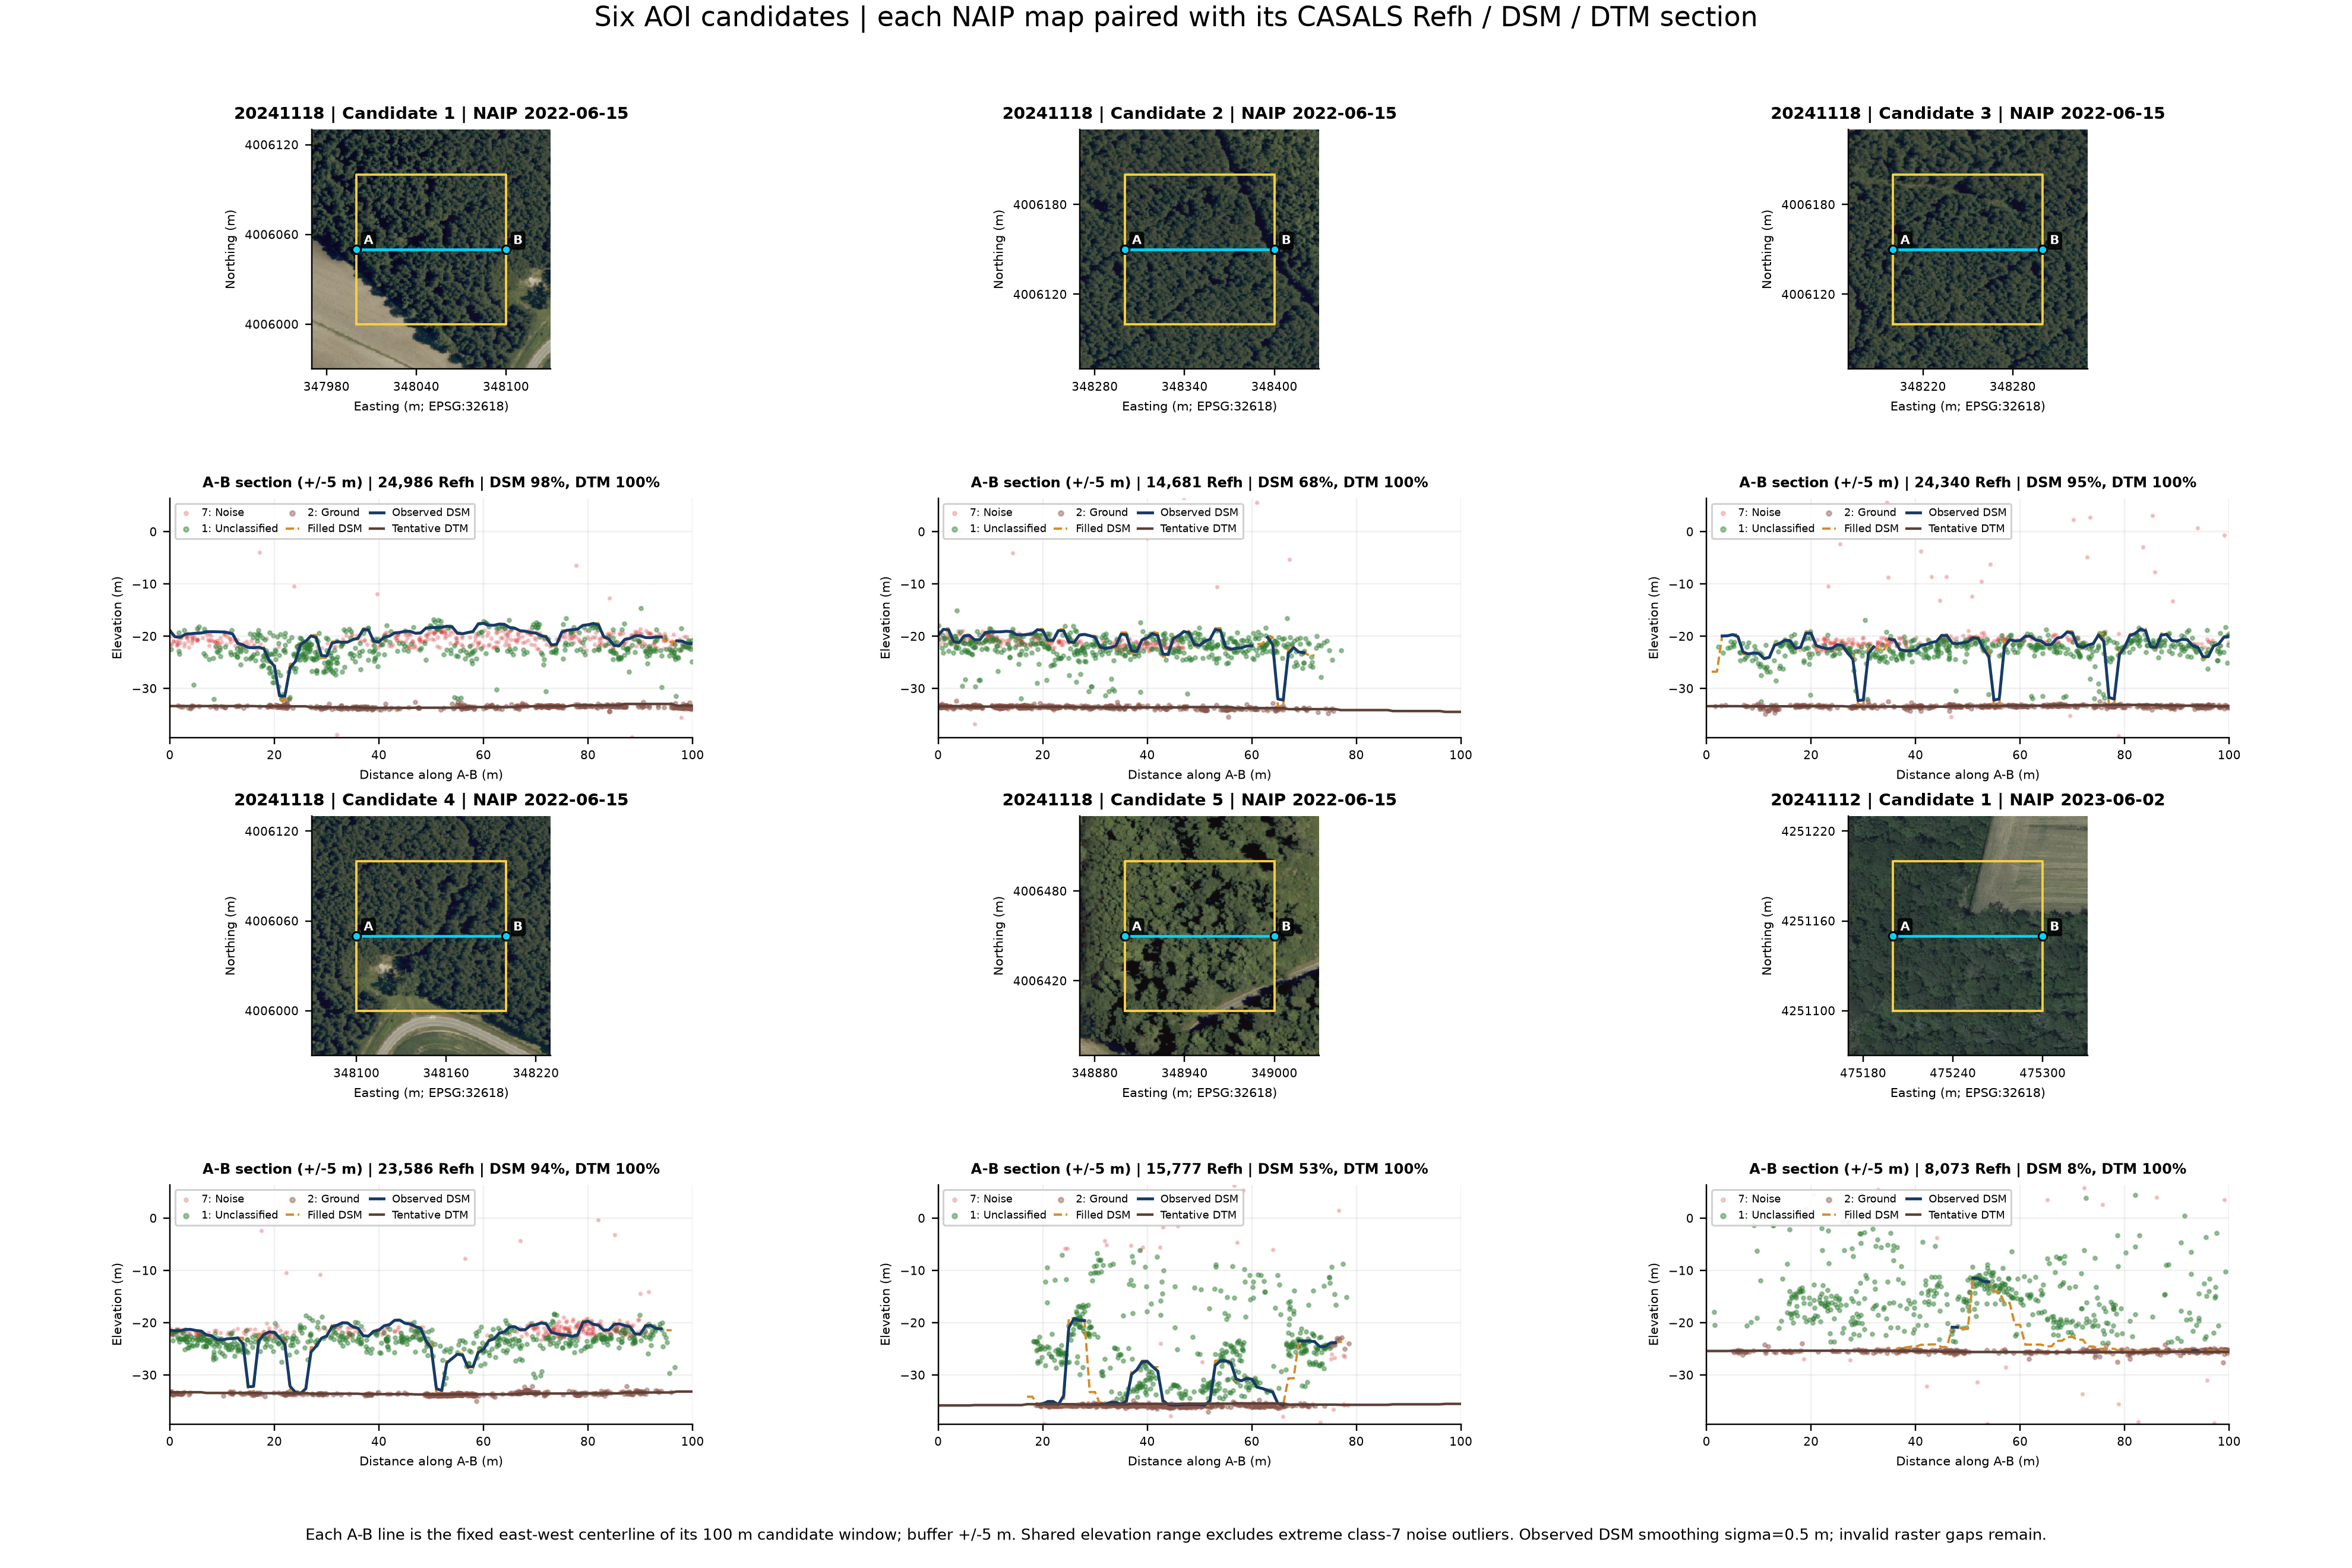

In [2]:
candidate_tables = []
for granule in GRANULES:
    out = ROOT / 'outputs/notebooks/05_forest_transect_showcase' / granule.stem
    candidates = screen_granule(granule, out, SCREEN_WINDOW_M, SCREEN_GRID_STEP_M, classification_metadata=ROOT / 'outputs/classification/full_20261009' / granule.stem / (granule.stem+'_run_metadata.json'))
    candidate_tables.append(candidates)
    print(granule.name)
    display(candidates.head(5))
# Pair five November 18 candidates with the best November 12 candidate.
candidate_specs = [(1, i) for i in range(5)] + [(0, 0)]
candidate_profiles = {}
candidate_sample_frames = []
candidate_profile_metadata = []

for gi in sorted({item[0] for item in candidate_specs}):
    granule = GRANULES[gi]
    granule_out = ROOT / 'outputs/notebooks/05_forest_transect_showcase' / granule.stem
    class_meta_path = ROOT / 'outputs/classification/full_20261009' / granule.stem / (granule.stem + '_run_metadata.json')
    profile_points, profile_xy, profile_crs = load_points(granule)
    profile_classes, _ = load_classes(granule, profile_points.pulse_index, class_meta_path)
    profile_dsm, profile_dtm, _ = ensure_surfaces(granule, granule_out)

    with rasterio.open(profile_dsm['strict_dsm_tif']) as ds:
        candidate_dsm_resolution_m = float(ds.res[0])
    with rasterio.open(profile_dtm['dtm_tif']) as ds:
        candidate_dtm_resolution_m = float(ds.res[0])

    for card_number, (spec_gi, rank) in enumerate(candidate_specs, start=1):
        if spec_gi != gi:
            continue
        row = candidate_tables[gi].iloc[rank]
        gx, gy = int(row.gx), int(row.gy)
        x0, y0 = gx * SCREEN_WINDOW_M, gy * SCREEN_WINDOW_M
        x1, y1 = x0 + SCREEN_WINDOW_M, y0 + SCREEN_WINDOW_M
        a = np.array([x0, y0 + SCREEN_WINDOW_M / 2], dtype=float)
        b = np.array([x1, y0 + SCREEN_WINDOW_M / 2], dtype=float)
        length_m = float(np.linalg.norm(b - a))
        candidate_id = f'{granule.stem}_candidate_{rank + 1}'

        # Restrict the full scalar arrays to the candidate window before projecting points onto A-B.
        local_mask = ((profile_xy[:, 0] >= x0) & (profile_xy[:, 0] <= x1) &
                      (profile_xy[:, 1] >= y0 - BUFFER_HALF_WIDTH_M) &
                      (profile_xy[:, 1] <= y1 + BUFFER_HALF_WIDTH_M))
        local_xy = profile_xy[local_mask]
        along_m, cross_m = transect_coordinates(local_xy, a, b)
        keep = ((along_m >= 0) & (along_m <= length_m) &
                (cross_m <= BUFFER_HALF_WIDTH_M))
        point_xy = local_xy[keep].copy()
        point_data = {
            'pulse_index': profile_points.pulse_index[local_mask][keep].copy(),
            'distance_m': along_m[keep].copy(),
            'cross_distance_m': cross_m[keep].copy(),
            'X': point_xy[:, 0],
            'Y': point_xy[:, 1],
            'refh_height_m': profile_points.z_refh[local_mask][keep].copy(),
            'class': profile_classes[local_mask][keep].copy(),
            'SNR': profile_points.refh_snr[local_mask][keep].copy(),
        }

        distances_m = np.r_[np.arange(0.0, length_m, PROFILE_STEP_M), length_m]
        samples_xy = a + distances_m[:, None] * (b - a) / length_m
        observed_m, observed_valid = sample_raster(
            profile_dsm['strict_dsm_tif'], samples_xy, profile_crs, profile_dsm['support_mask_tif'])
        filled_m, filled_valid = sample_raster(
            profile_dsm['filled_dsm_tif'], samples_xy, profile_crs, profile_dsm['support_mask_tif'])
        dtm_m, dtm_valid = sample_raster(
            profile_dtm['dtm_tif'], samples_xy, profile_crs, profile_dtm['support_mask_tif'])
        observed_display_m = smooth_observed_dsm(observed_m)
        assert np.array_equal(np.isfinite(observed_display_m), observed_valid)

        candidate_profiles[candidate_id] = {
            'granule': granule,
            'rank': rank + 1,
            'gx': gx,
            'gy': gy,
            'crs': profile_crs,
            'a': a,
            'b': b,
            'length_m': length_m,
            'distances_m': distances_m,
            'samples_xy': samples_xy,
            'observed_m': observed_m,
            'observed_valid': observed_valid,
            'observed_display_m': observed_display_m,
            'filled_m': filled_m,
            'filled_valid': filled_valid,
            'dtm_m': dtm_m,
            'dtm_valid': dtm_valid,
            'point_data': point_data,
            'dsm_resolution_m': candidate_dsm_resolution_m,
            'dtm_resolution_m': candidate_dtm_resolution_m,
            'source_products': (profile_dsm, profile_dtm),
        }

        candidate_sample_frames.append(pd.DataFrame({
            'candidate_id': candidate_id,
            'h5': relative(granule),
            'crs': f'EPSG:{profile_crs}',
            'distance_m': distances_m,
            'X': samples_xy[:, 0],
            'Y': samples_xy[:, 1],
            'observed_dsm_m': observed_m,
            'observed_dsm_valid': observed_valid,
            'observed_dsm_display_m': observed_display_m,
            'filled_dsm_m': filled_m,
            'filled_dsm_valid': filled_valid,
            'dtm_m': dtm_m,
            'dtm_valid': dtm_valid,
        }))
        candidate_profile_metadata.append({
            'candidate_id': candidate_id,
            'h5': relative(granule),
            'candidate_rank': rank + 1,
            'grid_x': gx,
            'grid_y': gy,
            'crs': f'EPSG:{profile_crs}',
            'A_X': a[0],
            'A_Y': a[1],
            'B_X': b[0],
            'B_Y': b[1],
            'length_m': length_m,
            'buffer_half_width_m': BUFFER_HALF_WIDTH_M,
            'refh_points_in_profile': len(point_data['pulse_index']),
            'observed_dsm_support_fraction': float(observed_valid.mean()),
            'filled_dsm_support_fraction': float(filled_valid.mean()),
            'dtm_support_fraction': float(dtm_valid.mean()),
            'dsm_resolution_m': candidate_dsm_resolution_m,
            'dtm_resolution_m': candidate_dtm_resolution_m,
            'observed_dsm_display_sigma_m': OBSERVED_DSM_SMOOTH_SIGMA_M,
        })

    del profile_points, profile_xy, profile_classes, profile_dsm, profile_dtm

# Use a shared elevation range for visual comparison; extreme class-7 values do not set the scale.
profile_elevation_values = []
for data in candidate_profiles.values():
    pdata = data['point_data']
    nonnoise = pdata['class'] != 7
    if nonnoise.any():
        profile_elevation_values.append(pdata['refh_height_m'][nonnoise])
    else:
        profile_elevation_values.append(pdata['refh_height_m'])
    profile_elevation_values.extend([
        data['observed_m'][data['observed_valid']],
        data['filled_m'][data['filled_valid']],
        data['dtm_m'][data['dtm_valid']],
    ])
profile_elevation_values = np.concatenate([v[np.isfinite(v)] for v in profile_elevation_values if np.isfinite(v).any()])
candidate_profile_ylim = (float(profile_elevation_values.min() - 2), float(profile_elevation_values.max() + 2))

candidate_colors = {1: '#2E7D32', 2: '#8c564b', 7: '#d62728'}
candidate_names = {1: '1: Unclassified', 2: '2: Ground', 7: '7: Noise'}
candidate_fig = plt.figure(figsize=(18, 12), layout='constrained')
outer = candidate_fig.add_gridspec(2, 3, wspace=.1, hspace=.14)
candidate_axes = []

for card_index, (gi, rank) in enumerate(candidate_specs):
    granule = GRANULES[gi]
    candidate_id = f'{granule.stem}_candidate_{rank + 1}'
    data = candidate_profiles[candidate_id]
    x0, y0 = data['gx'] * SCREEN_WINDOW_M, data['gy'] * SCREEN_WINDOW_M
    bounds = [x0 - 30, y0 - 30, x0 + SCREEN_WINDOW_M + 30, y0 + SCREEN_WINDOW_M + 30]
    granule_out = ROOT / 'outputs/notebooks/05_forest_transect_showcase' / granule.stem
    ortho = granule_out / f'candidate_{rank + 1}_naip.tif'
    evidence = fetch_naip(bounds, data['crs'], ortho)

    card = outer[card_index // 3, card_index % 3].subgridspec(2, 1, height_ratios=[1.0, 1.0], hspace=.08)
    map_ax = candidate_fig.add_subplot(card[0])
    profile_ax = candidate_fig.add_subplot(card[1])
    show_ortho(map_ax, ortho)
    map_ax.plot([x0, x0 + SCREEN_WINDOW_M, x0 + SCREEN_WINDOW_M, x0, x0],
                [y0, y0, y0 + SCREEN_WINDOW_M, y0 + SCREEN_WINDOW_M, y0],
                color='#ffcf40', lw=1.25, zorder=3)
    map_ax.plot([data['a'][0], data['b'][0]], [data['a'][1], data['b'][1]],
                color='#00d5ff', lw=1.5, zorder=4)
    for letter, endpoint in zip('AB', [data['a'], data['b']]):
        map_ax.scatter(endpoint[0], endpoint[1], s=22, c='#00d5ff', edgecolors='black', zorder=5)
        map_ax.annotate(letter, endpoint, xytext=(4, 3), textcoords='offset points',
                        fontsize=7, weight='bold', color='white',
                        bbox=dict(fc='black', alpha=.75, pad=1, boxstyle='round,pad=.15'))
    map_ax.set_xlim(bounds[0], bounds[2])
    map_ax.set_ylim(bounds[1], bounds[3])
    map_ax.set_aspect('equal', adjustable='box')
    map_ax.set_xlabel(f'Easting (m; EPSG:{data["crs"]})', fontsize=7)
    map_ax.set_ylabel('Northing (m)', fontsize=7)
    map_ax.tick_params(labelsize=6.5)
    map_ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    map_ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    map_ax.set_title(f'{granule.stem[11:19]} | Candidate {rank + 1} | NAIP {",".join(evidence["acquisition_dates"])}', fontsize=9)

    pdata = data['point_data']
    for class_code in [7, 1, 2]:
        class_mask = pdata['class'] == class_code
        step = max(1, int(np.ceil(class_mask.sum() / 500)))
        profile_ax.scatter(pdata['distance_m'][class_mask][::step],
                           pdata['refh_height_m'][class_mask][::step],
                           s=4 if class_code != 7 else 2.5,
                           color=candidate_colors[class_code],
                           alpha=.42 if class_code != 7 else .2,
                           label=candidate_names[class_code], rasterized=True)
    profile_ax.plot(data['distances_m'], data['filled_m'], color='#d58a27', ls='--', lw=1.25, label='Filled DSM')
    profile_ax.plot(data['distances_m'], data['observed_display_m'], color='#153b69', lw=1.6, label='Observed DSM')
    profile_ax.plot(data['distances_m'], data['dtm_m'], color='#5D4037', lw=1.4, label='Tentative DTM')
    profile_ax.set_xlim(0, data['length_m'])
    profile_ax.set_ylim(candidate_profile_ylim)
    profile_ax.set_aspect('equal', adjustable='box')
    profile_ax.set_xlabel('Distance along A-B (m)', fontsize=7)
    profile_ax.set_ylabel('Elevation (m)', fontsize=7)
    profile_ax.tick_params(labelsize=6.5)
    profile_ax.grid(alpha=.18)
    strict_fraction = float(data['observed_valid'].mean())
    dtm_fraction = float(data['dtm_valid'].mean())
    profile_ax.set_title(
        f'A-B section (+/-{BUFFER_HALF_WIDTH_M:g} m) | {len(pdata["pulse_index"]):,} Refh | DSM {strict_fraction:.0%}, DTM {dtm_fraction:.0%}',
        fontsize=8)
    profile_ax.legend(loc='upper left', ncol=3, fontsize=5.8, framealpha=.9,
                      handlelength=1.3, columnspacing=.7, markerscale=1.3)
    candidate_axes.append((map_ax, profile_ax, candidate_id))

candidate_fig.suptitle('Six AOI candidates | each NAIP map paired with its CASALS Refh / DSM / DTM section', fontsize=15)
candidate_fig.get_layout_engine().set(rect=(.02, .06, .98, .90))
candidate_fig.text(.5, .018,
    f'Each A-B line is the fixed east-west centerline of its 100 m candidate window; buffer +/-{BUFFER_HALF_WIDTH_M:g} m. Shared elevation range excludes extreme class-7 noise outliers. Observed DSM smoothing sigma={OBSERVED_DSM_SMOOTH_SIGMA_M:g} m; invalid raster gaps remain.',
    ha='center', fontsize=8.5)
candidate_fig.canvas.draw()
for map_ax, profile_ax, candidate_id in candidate_axes:
    assert_equal_metre_scale(map_ax, candidate_id + ' map', draw=False)
    assert_equal_metre_scale(profile_ax, candidate_id + ' profile', draw=False)

candidate_fig.savefig(OUTPUT_DIR / 'candidate_evidence_board.png', dpi=DPI)
plt.close(candidate_fig)
candidate_samples = pd.concat(candidate_sample_frames, ignore_index=True)
candidate_samples.to_csv(OUTPUT_DIR / 'candidate_profile_samples.csv', index=False)
candidate_profile_metadata = pd.DataFrame(candidate_profile_metadata)
candidate_profile_metadata.to_csv(OUTPUT_DIR / 'candidate_profile_metadata.csv', index=False)
display(candidate_profile_metadata)
display(Image(filename=str(OUTPUT_DIR / 'candidate_evidence_board.png')))


## Selected AOI and reproducible straight transect
Visual review of all five November 18 candidates finds textured tree crowns and shadows. Candidate 1 includes a field edge and a small clearing, providing useful lower-surface contrast; candidates 2–3 are dominated by canopy. Candidate 4 includes a road and clearing; candidate 5 has a road and possible mixed footprints. The November 12 image also contains trees, but the retained high-SNR Refh points provide little supported elevated structure there.

The selected default line crosses lower Refh return zones at the swath edges and elevated structures within the historically tree-covered area. The visually appealing field-to-clearing line lies outside the sampled strip and is rejected. Lower Refh zones are not automatically open ground. NAIP 2022-06-15 is independent evidence of historical tree cover, not exact 2024 footprint truth. No image-to-CASALS shift was fitted. Coordinates are pinned rather than reselected randomly each execution.

In [3]:
points, xy, CRS = load_points(H5_PATH)
ACQUISITION_DATE = str(points.attrs['start_utca']).split('T')[0]
classes, class_metadata = load_classes(H5_PATH,points.pulse_index, CLASSIFICATION_METADATA)
dsm, dtm, product_metadata = ensure_surfaces(H5_PATH,OUTPUT_DIR)
ortho = OUTPUT_DIR/'aoi_naip.tif'
evidence = fetch_naip(AOI,CRS,ortho)
with rasterio.open(dsm['strict_dsm_tif']) as ds: DSM_RES = list(ds.res);DSM_CRS = str(ds.crs)
with rasterio.open(dtm['dtm_tif']) as ds: DTM_RES = list(ds.res);DTM_CRS = str(ds.crs)
s, cross = transect_coordinates(xy,A,B)
length = float(np.linalg.norm(B-A))
keep = (s>=0)&(s<=length)&(cross<=BUFFER_HALF_WIDTH_M)
point_table = pd.DataFrame({'pulse_index':points.pulse_index[keep], 'X':xy[keep,0], 'Y':xy[keep,1],
             'refh_height_m':points.z_refh[keep], 'distance_m':s[keep], 'cross_distance_m':cross[keep],
             'class':classes[keep], 'SNR':points.refh_snr[keep]})
distances = np.r_[np.arange(0,length,PROFILE_STEP_M),length]
samples_xy = A+distances[:,None]*(B-A)/length
sample_table = pd.DataFrame({'distance_m':distances,'X':samples_xy[:,0],'Y':samples_xy[:,1]})
for name,path,support in [('strict_dsm',dsm['strict_dsm_tif'],dsm['support_mask_tif']),
                          ('filled_dsm',dsm['filled_dsm_tif'],dsm['support_mask_tif']),
                          ('dtm',dtm['dtm_tif'],dtm['support_mask_tif'])]:
    values, valid = sample_raster(path,samples_xy,CRS,support)
    sample_table[name+'_m'] = values
    sample_table[name+'_valid'] = valid
for name,path in [('dsm_support',dsm['support_mask_tif']),('dsm_fill_source',dsm['fill_source_tif']),
                   ('dtm_support',dtm['support_mask_tif']),('dtm_source',dtm['source_mask_tif']),
                   ('nearest_ground_distance_m',dtm['nearest_ground_distance_tif'])]:
    sample_table[name],_ = sample_raster(path,samples_xy,CRS)
sample_table['dsm_interpolated'] = sample_table.filled_dsm_valid & ~sample_table.strict_dsm_valid
assert len(point_table)>100 and sample_table.strict_dsm_valid.mean()>=.3, 'Insufficient actual Refh/strict DSM support'
assert sample_table.dtm_valid.mean() >= .8, 'Reconsider this transect: insufficient DTM support'
point_table.to_csv(OUTPUT_DIR/'transect_points.csv',index=False)
sample_table.to_csv(OUTPUT_DIR/'transect_samples.csv',index=False)
display(sample_table[['strict_dsm_valid','filled_dsm_valid','dtm_valid','dsm_interpolated']].mean().rename('profile_sample_fraction'))
print(f'{len(point_table):,} Refh points; length {length:.2f} m; buffer ±{BUFFER_HALF_WIDTH_M:g} m')


strict_dsm_valid    0.960265
filled_dsm_valid    1.000000
dtm_valid           1.000000
dsm_interpolated    0.039735
Name: profile_sample_fraction, dtype: float64

36,763 Refh points; length 150.00 m; buffer ±5 m


## Main figures
The blue Observed DSM uses only supported, strictly observed cells and is lightly Gaussian-smoothed (sigma 0.5 m) for display. Smoothing is applied separately within each contiguous valid segment; `transect_samples.csv` retains the unfiltered raster samples and NaN gaps are not bridged. The orange dashed DSM shows the support-limited filled surface and is labelled as such. The tentative DTM is sampled independently at its own resolution.

Class 1 is **Unclassified**, never vegetation. Noise points remain in the CSV and full-range inset. The main profile uses the non-noise elevation range for readability; counts outside that displayed range are recorded.

AOI orthophoto map: X 1 m = 3.4465px; Y 1 m = 3.4465px


AOI HAG map: X 1 m = 3.8019px; Y 1 m = 3.8019px


Three-class transect profile: X 1 m = 11.5207px; Y 1 m = 11.5207px


Ground vs non-ground profile: X 1 m = 11.5207px; Y 1 m = 11.5207px


Comparison board spatial map: X 1 m = 2.1466px; Y 1 m = 2.1466px


Comparison board transect profile: X 1 m = 8.0140px; Y 1 m = 8.0140px


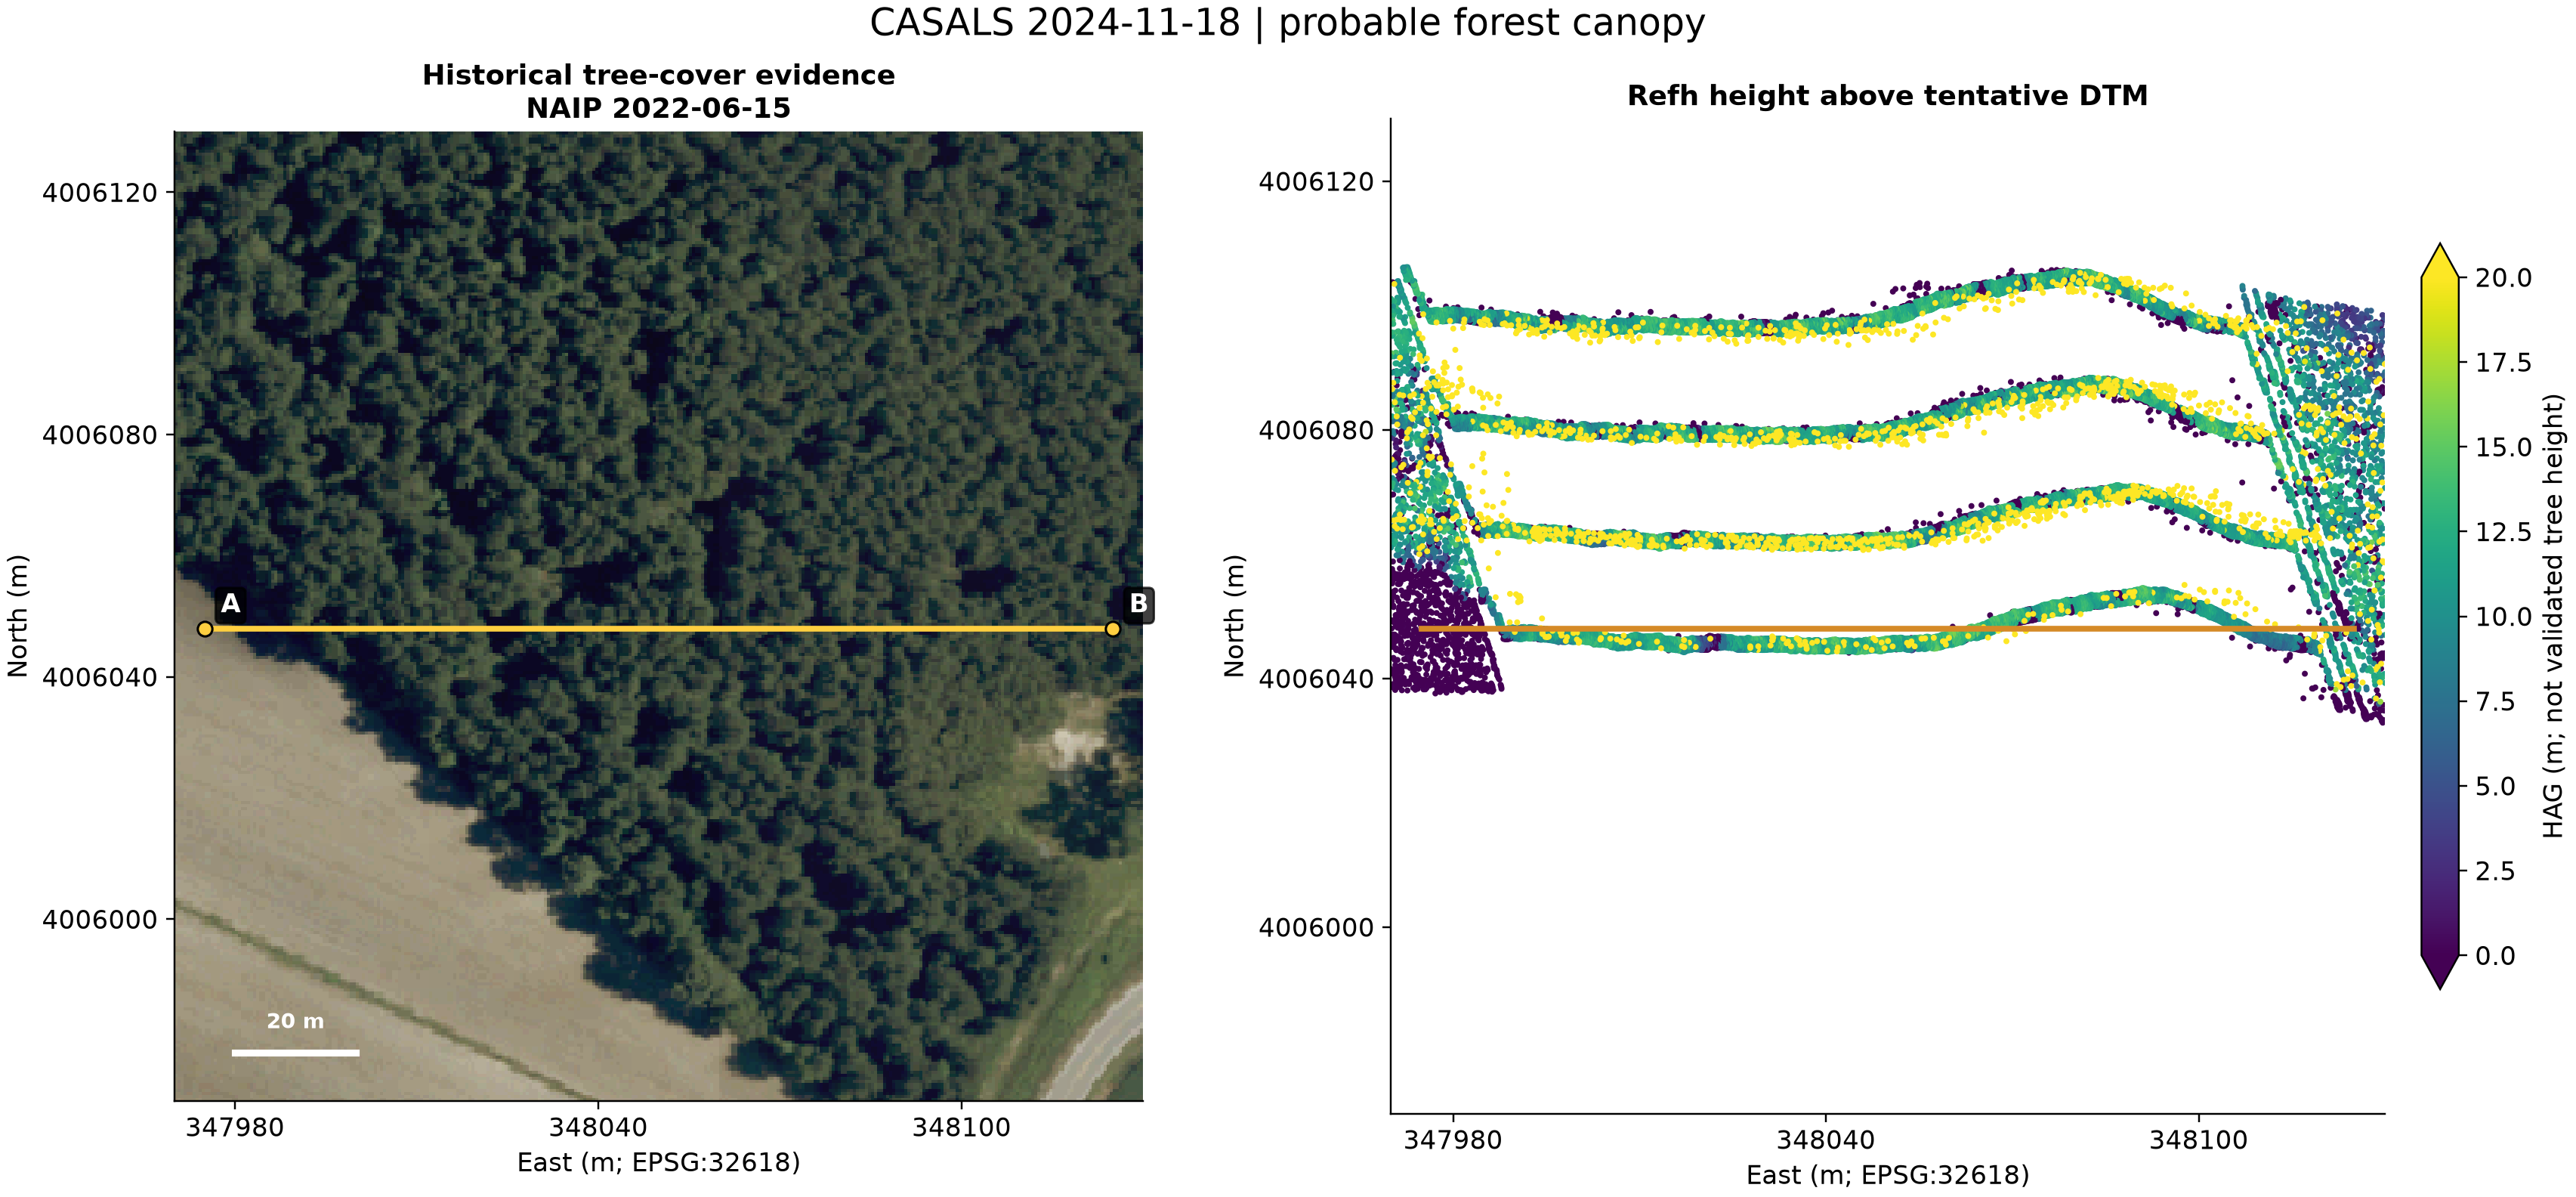

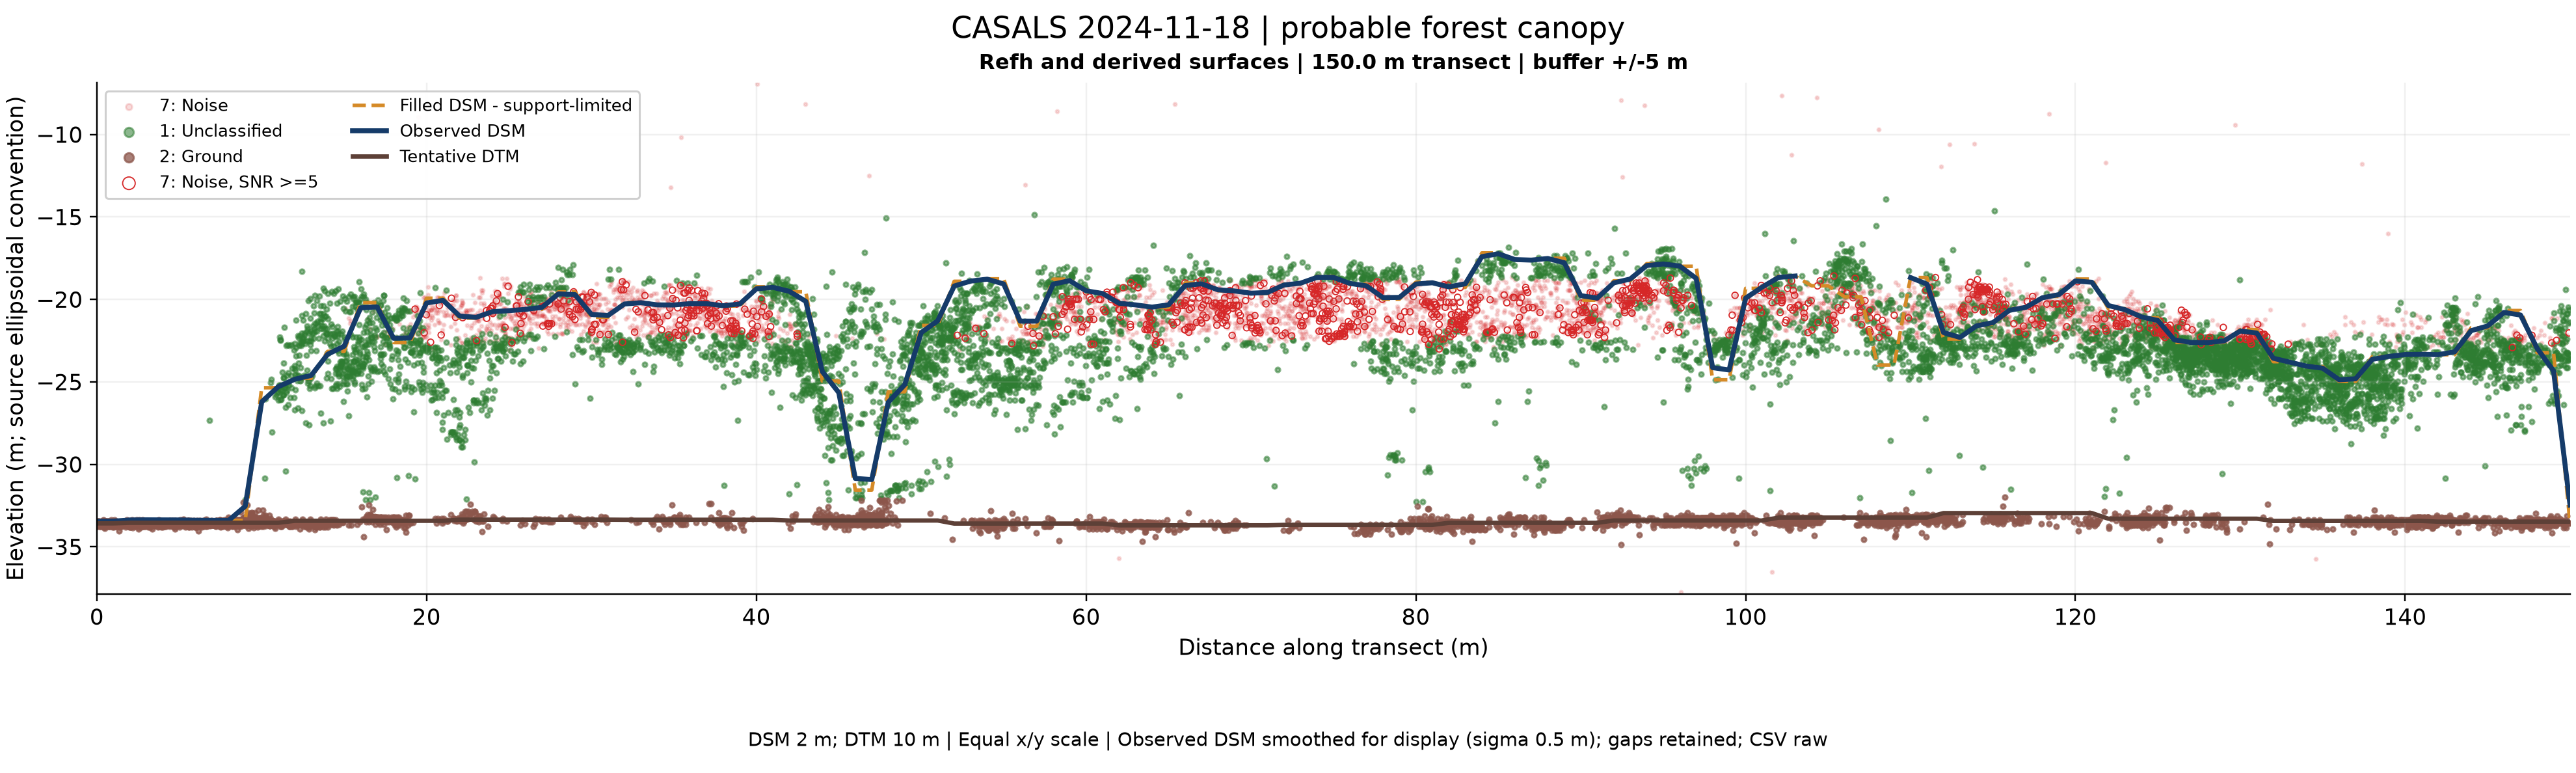

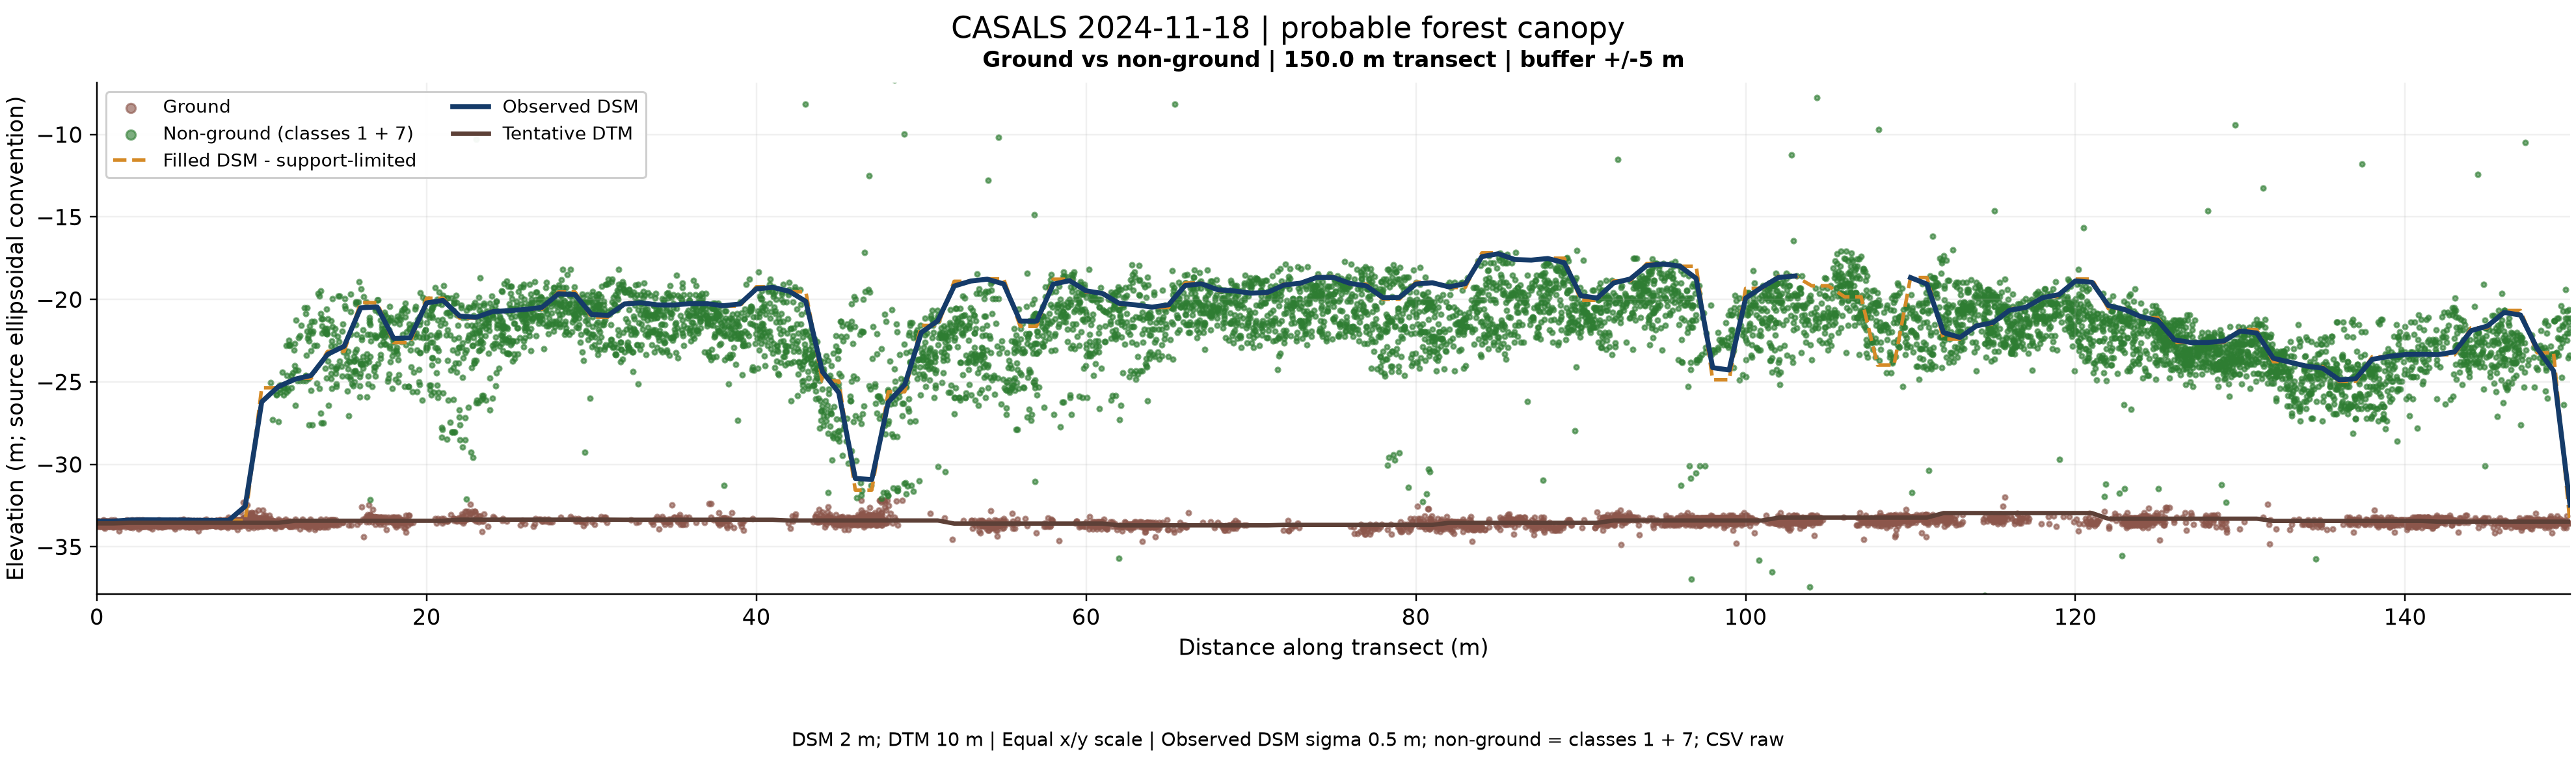

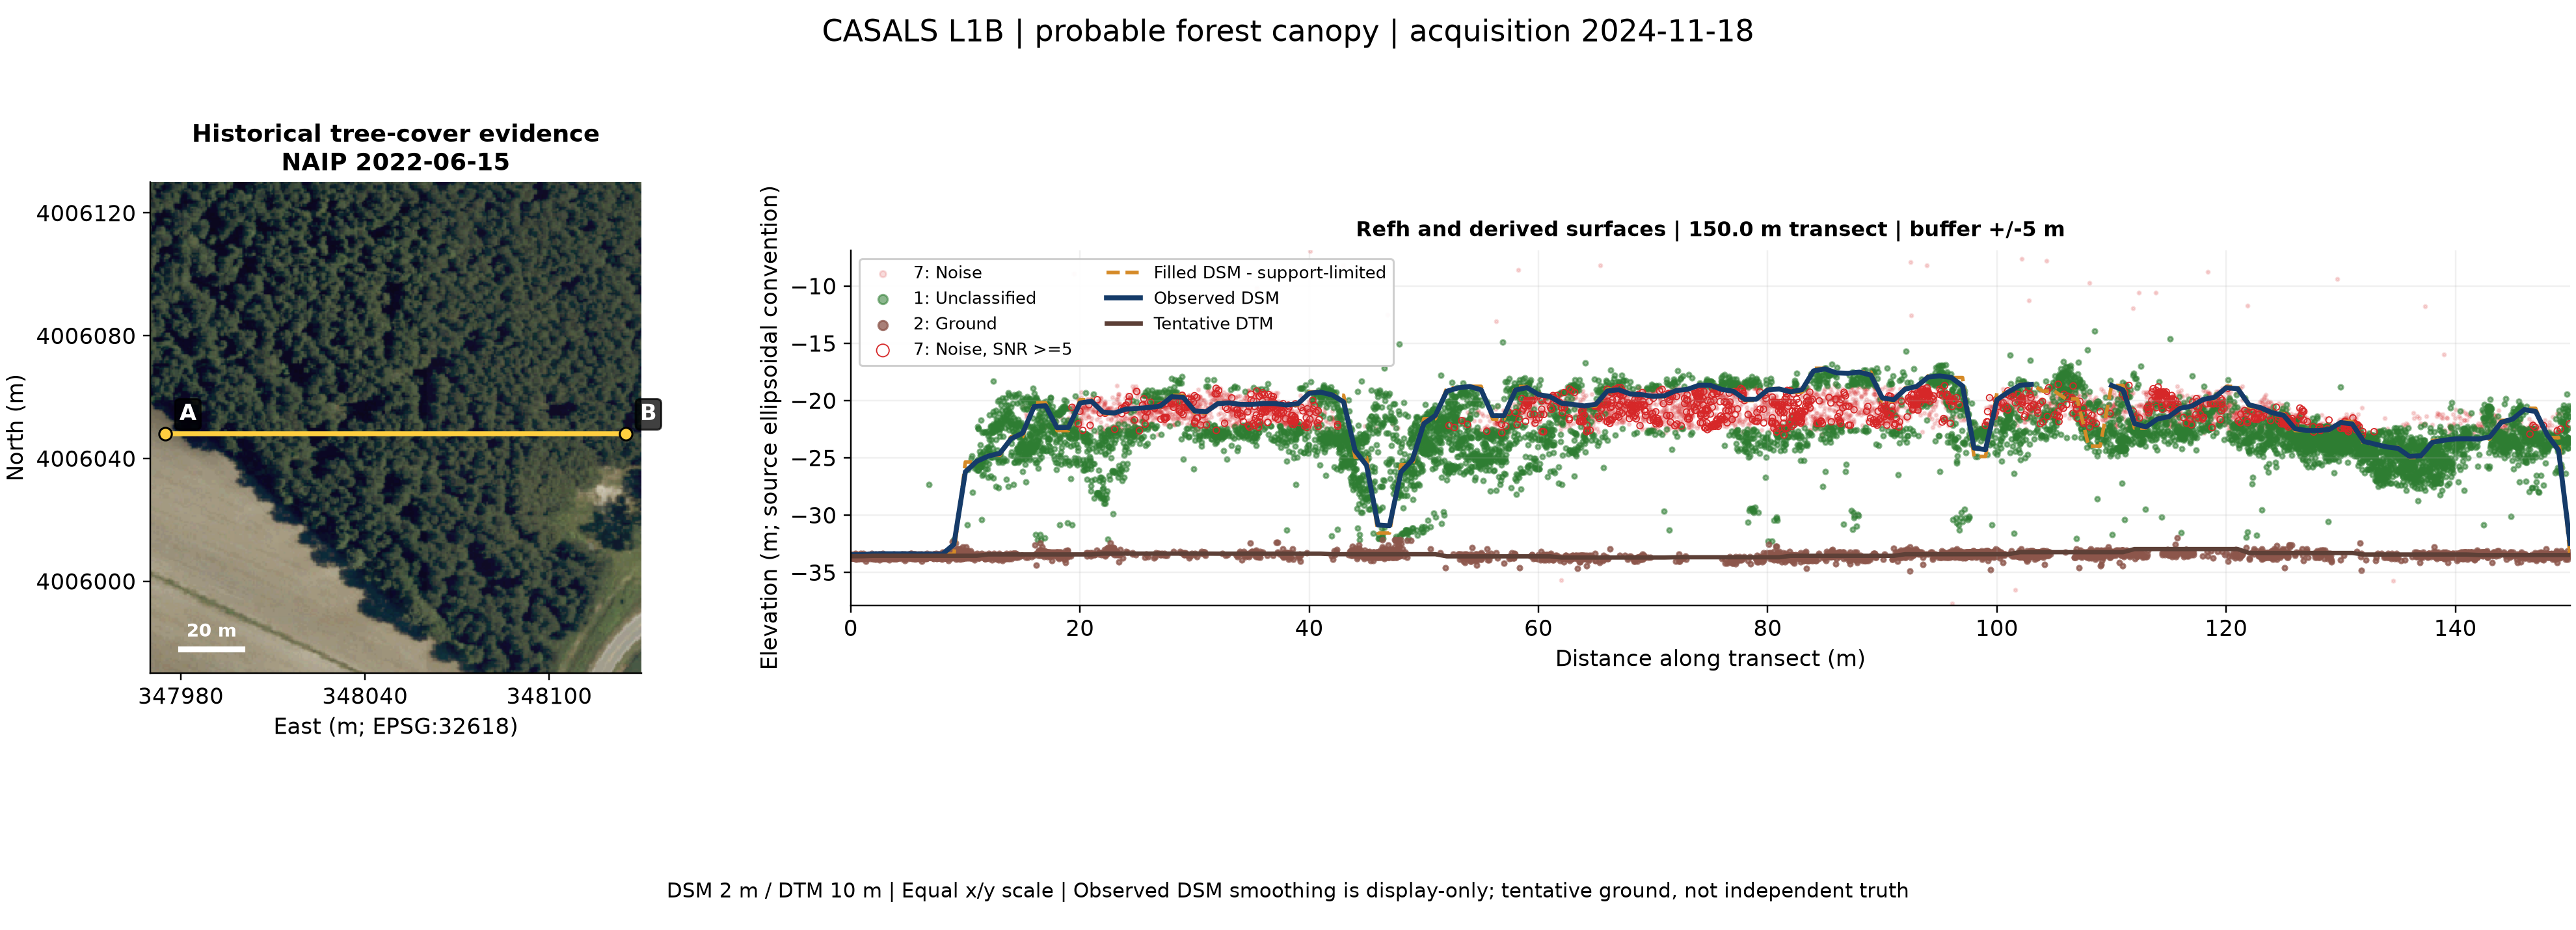

In [4]:
COLORS = {1: '#2E7D32', 2: '#8c564b', 7: '#d62728'}
NAMES = {1: '1: Unclassified', 2: '2: Ground', 7: '7: Noise'}
inside_aoi = (xy[:,0]>=AOI[0])&(xy[:,0]<=AOI[2])&(xy[:,1]>=AOI[1])&(xy[:,1]<=AOI[3])
ground_aoi,_ = sample_raster(dtm['dtm_tif'],xy[inside_aoi],CRS,dtm['support_mask_tif'])
hag_aoi = points.z_refh[inside_aoi]-ground_aoi


def spatial(ax):
    show_ortho(ax,ortho)
    ax.plot(*np.vstack([A,B]).T,color='#ffcf40',lw=2.5)
    for letter,p in zip('AB',[A,B]):
        ax.scatter(*p,c='#ffcf40',s=40,edgecolors='black',zorder=4)
        ax.annotate(letter,p,xytext=(7,7),textcoords='offset points',color='white',weight='bold',
                    bbox=dict(fc='black',alpha=.75,pad=2,boxstyle='round,pad=0.2'))
    ax.set_xlabel(f'East (m; EPSG:{CRS})');ax.set_ylabel('North (m)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(3));ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.set_title('Historical tree-cover evidence\nNAIP '+','.join(evidence['acquisition_dates']),fontsize=12)
    ax.plot([AOI[0]+10,AOI[0]+30],[AOI[1]+8]*2,c='white',lw=3)
    ax.text(AOI[0]+20,AOI[1]+12,'20 m',ha='center',color='white',fontsize=9,weight='bold')
observed_dsm_display_m = smooth_observed_dsm(sample_table.strict_dsm_m.to_numpy())
assert np.array_equal(np.isfinite(observed_dsm_display_m), sample_table.strict_dsm_valid.to_numpy()), 'Display smoothing must preserve observed-data gaps.'

def profile(ax):
    # Class colors are fixed across the profile and presentation board.
    for c in [7,1,2]:
        g = point_table[point_table['class']==c]
        g = g.iloc[::max(1,int(np.ceil(len(g)/8000)))]
        ax.scatter(g.distance_m,g.refh_height_m,s=2.5 if c==7 else 5.5,c=COLORS[c],alpha=.16 if c==7 else (.55 if c==1 else .75),
                   label=NAMES[c],rasterized=True)
    high_noise=point_table[(point_table['class']==7)&(point_table.SNR>=5)]
    ax.scatter(high_noise.distance_m,high_noise.refh_height_m,s=10,facecolors='none',edgecolors=COLORS[7],lw=.6,label='7: Noise, SNR >=5',rasterized=True)
    ax.plot(distances,sample_table.filled_dsm_m,color='#d58a27',ls='--',lw=1.8,label='Filled DSM - support-limited')
    ax.plot(distances,observed_dsm_display_m,color='#153b69',lw=2.5,label='Observed DSM')
    ax.plot(distances,sample_table.dtm_m,color='#5D4037',lw=2.2,label='Tentative DTM')
    nonnoise = point_table.loc[point_table['class']!=7,'refh_height_m']
    limits = [min(nonnoise.min(),sample_table.dtm_m.min())-3,max(nonnoise.max(),sample_table.filled_dsm_m.max())+7]
    ax.set_ylim(limits);ax.set_xlim(0,length);ax.set_aspect('equal',adjustable='box')
    ax.set_xlabel('Distance along transect (m)');ax.set_ylabel('Elevation (m; source ellipsoidal convention)')
    ax.grid(alpha=.18);ax.legend(loc='upper left',ncol=2,fontsize=8.5,markerscale=2,framealpha=0.94)
    ax.set_title(f'Refh and derived surfaces | {length:.1f} m transect | buffer +/-{BUFFER_HALF_WIDTH_M:g} m',fontsize=10.5,pad=7)
    return limits

def binary_profile(ax):
    groups=[(point_table[point_table['class']==2], '#8c564b', 'Ground'),
            (point_table[point_table['class']!=2], '#2E7D32', 'Non-ground (classes 1 + 7)')]
    for g,color,label in groups:
        g=g.iloc[::max(1,int(np.ceil(len(g)/8000)))]
        ax.scatter(g.distance_m,g.refh_height_m,s=5.5,c=color,alpha=.62,label=label,rasterized=True)
    ax.plot(distances,sample_table.filled_dsm_m,color='#d58a27',ls='--',lw=1.8,label='Filled DSM - support-limited')
    ax.plot(distances,observed_dsm_display_m,color='#153b69',lw=2.5,label='Observed DSM')
    ax.plot(distances,sample_table.dtm_m,color='#5D4037',lw=2.2,label='Tentative DTM')
    nonnoise=point_table.loc[point_table['class']!=7,'refh_height_m']
    limits=[min(nonnoise.min(),sample_table.dtm_m.min())-3,
            max(nonnoise.max(),sample_table.filled_dsm_m.max())+7]
    ax.set_xlim(0,length);ax.set_ylim(limits);ax.set_aspect('equal',adjustable='box')
    ax.set_xlabel('Distance along transect (m)')
    ax.set_ylabel('Elevation (m; source ellipsoidal convention)')
    ax.grid(alpha=.18);ax.legend(loc='upper left',ncol=2,fontsize=9,markerscale=2,framealpha=.94)
    ax.set_title(f'Ground vs non-ground | {length:.1f} m transect | buffer +/-{BUFFER_HALF_WIDTH_M:g} m',fontsize=11,pad=8)
    return limits

fig,ax = plt.subplots(1,2,figsize=(15.5,7.2),gridspec_kw={'width_ratios':[1,1.25]},layout='constrained')
spatial(ax[0])
view = xy[inside_aoi];thin = np.arange(0,len(view),max(1,len(view)//30000))
im = ax[1].scatter(view[thin,0],view[thin,1],c=hag_aoi[thin],s=2.5,cmap='viridis',vmin=0,vmax=20,rasterized=True)
ax[1].plot(*np.vstack([A,B]).T,c='#d58a27',lw=2.5);ax[1].set_aspect('equal')
ax[1].set_xlim(AOI[0],AOI[2]);ax[1].set_ylim(AOI[1],AOI[3])
ax[1].set_title('Refh height above tentative DTM',fontsize=12);ax[1].set_xlabel(f'East (m; EPSG:{CRS})');ax[1].set_ylabel('North (m)')
ax[1].ticklabel_format(useOffset=False,style='plain');ax[1].xaxis.set_major_locator(plt.MaxNLocator(3));ax[1].yaxis.set_major_locator(plt.MaxNLocator(4))
fig.colorbar(im,ax=ax[1],label='HAG (m; not validated tree height)',shrink=.75,pad=.03,extend='both')
fig.suptitle(f'CASALS {ACQUISITION_DATE} | {LAND_COVER}',fontsize=16)
assert_equal_metre_scale(ax[0], 'AOI orthophoto map')
assert_equal_metre_scale(ax[1], 'AOI HAG map')
fig.savefig(OUTPUT_DIR/'aoi_overview.png',dpi=DPI);plt.close(fig)
fig,ax=plt.subplots(figsize=(18,5.4),layout='constrained')
fig.get_layout_engine().set(rect=(0,.14,1,.82))
main_limits=profile(ax)
fig.suptitle(f'CASALS {ACQUISITION_DATE} | {LAND_COVER}',fontsize=15,y=.98)
fig.text(.5,.035,f'DSM {DSM_RES[0]:g} m; DTM {DTM_RES[0]:g} m | Equal x/y scale | Observed DSM smoothed for display (sigma {OBSERVED_DSM_SMOOTH_SIGMA_M:g} m); gaps retained; CSV raw',ha='center',fontsize=9.5)
assert_equal_metre_scale(ax, 'Three-class transect profile')
fig.savefig(OUTPUT_DIR/'transect_profile.png',dpi=DPI);plt.close(fig)
fig,ax=plt.subplots(figsize=(18,5.4),layout='constrained')
fig.get_layout_engine().set(rect=(0,.14,1,.82))
binary_limits=binary_profile(ax)
fig.suptitle(f'CASALS {ACQUISITION_DATE} | {LAND_COVER}',fontsize=15,y=.98)
fig.text(.5,.035,f'DSM {DSM_RES[0]:g} m; DTM {DTM_RES[0]:g} m | Equal x/y scale | Observed DSM sigma {OBSERVED_DSM_SMOOTH_SIGMA_M:g} m; non-ground = classes 1 + 7; CSV raw',ha='center',fontsize=9.5)
assert_equal_metre_scale(ax, 'Ground vs non-ground profile')
fig.savefig(OUTPUT_DIR/'transect_profile_ground_vs_nonground.png',dpi=DPI);plt.close(fig)
fig = plt.figure(figsize=(18,6.5),layout='constrained')
fig.get_layout_engine().set(rect=(0,.12,1,.84))
gs=fig.add_gridspec(1,2,width_ratios=[1,3.5],wspace=.08)
board_map_ax=fig.add_subplot(gs[0]);board_profile_ax=fig.add_subplot(gs[1])
spatial(board_map_ax);profile(board_profile_ax)
fig.suptitle(f'CASALS L1B | {LAND_COVER} | acquisition {ACQUISITION_DATE}',fontsize=15,y=.98)
fig.text(.5,.035,f'DSM {DSM_RES[0]:g} m / DTM {DTM_RES[0]:g} m | Equal x/y scale | Observed DSM smoothing is display-only; tentative ground, not independent truth',ha='center',fontsize=10)
assert_equal_metre_scale(board_map_ax, 'Comparison board spatial map')
assert_equal_metre_scale(board_profile_ax, 'Comparison board transect profile')
fig.savefig(OUTPUT_DIR/'transect_comparison_board.png',dpi=DPI);plt.close(fig)
for name in ['aoi_overview.png','transect_profile.png','transect_profile_ground_vs_nonground.png','transect_comparison_board.png']:
    display(Image(filename=str(OUTPUT_DIR/name)))

## Noise diagnosis
Saved classification reasons, HAG, SNR and track counts describe why records were labelled noise. The relative-height panel limits its display range; all points remain in the CSV and existing full-range profile inset. Rule labels are not validated physical causes.

{'noise_count': 16947,
 'noise_fraction': 0.46097978946223106,
 'noise_tracks': 73,
 'total_tracks': 76,
 'high_signal_HAG0to25_max_10m_p95_difference_m': 3.169520538755201,
 'reasons': {'noise_scanline_hag_outlier': 13697,
  'noise_above_max_hag': 1802,
  'noise_below_ground': 1362,
  'noise_low_density_processed_only': 86},
 'noise_elevation_quantiles_m': {0.0: -186.57765100794848,
  0.1: -22.580608221928692,
  0.5: -20.779586064693564,
  0.9: 9.450675782951294,
  1.0: 221.77933900315514},
 'noise_HAG_quantiles_m': {0.0: -153.17748257589588,
  0.1: 10.79750803926417,
  0.5: 12.621569589679531,
  0.9: 42.742581309887626,
  1.0: 255.21188752610436},
 'noise_SNR_quantiles': {0.0: 1.242307273630725,
  0.1: 1.9570808948250125,
  0.5: 3.0411396935512673,
  0.9: 4.647001250828237,
  1.0: 9.064648617283341},
 'low_SNR_below5_count': 15890,
 'nonfinite_stored_geometry_count': 0,
 'high_SNR_HAG5to25_count': 1057,
 'high_SNR_HAG5to25_occupied_10m_bins': 14,
 'max_10m_p95_all_minus_nonnoise_m': 

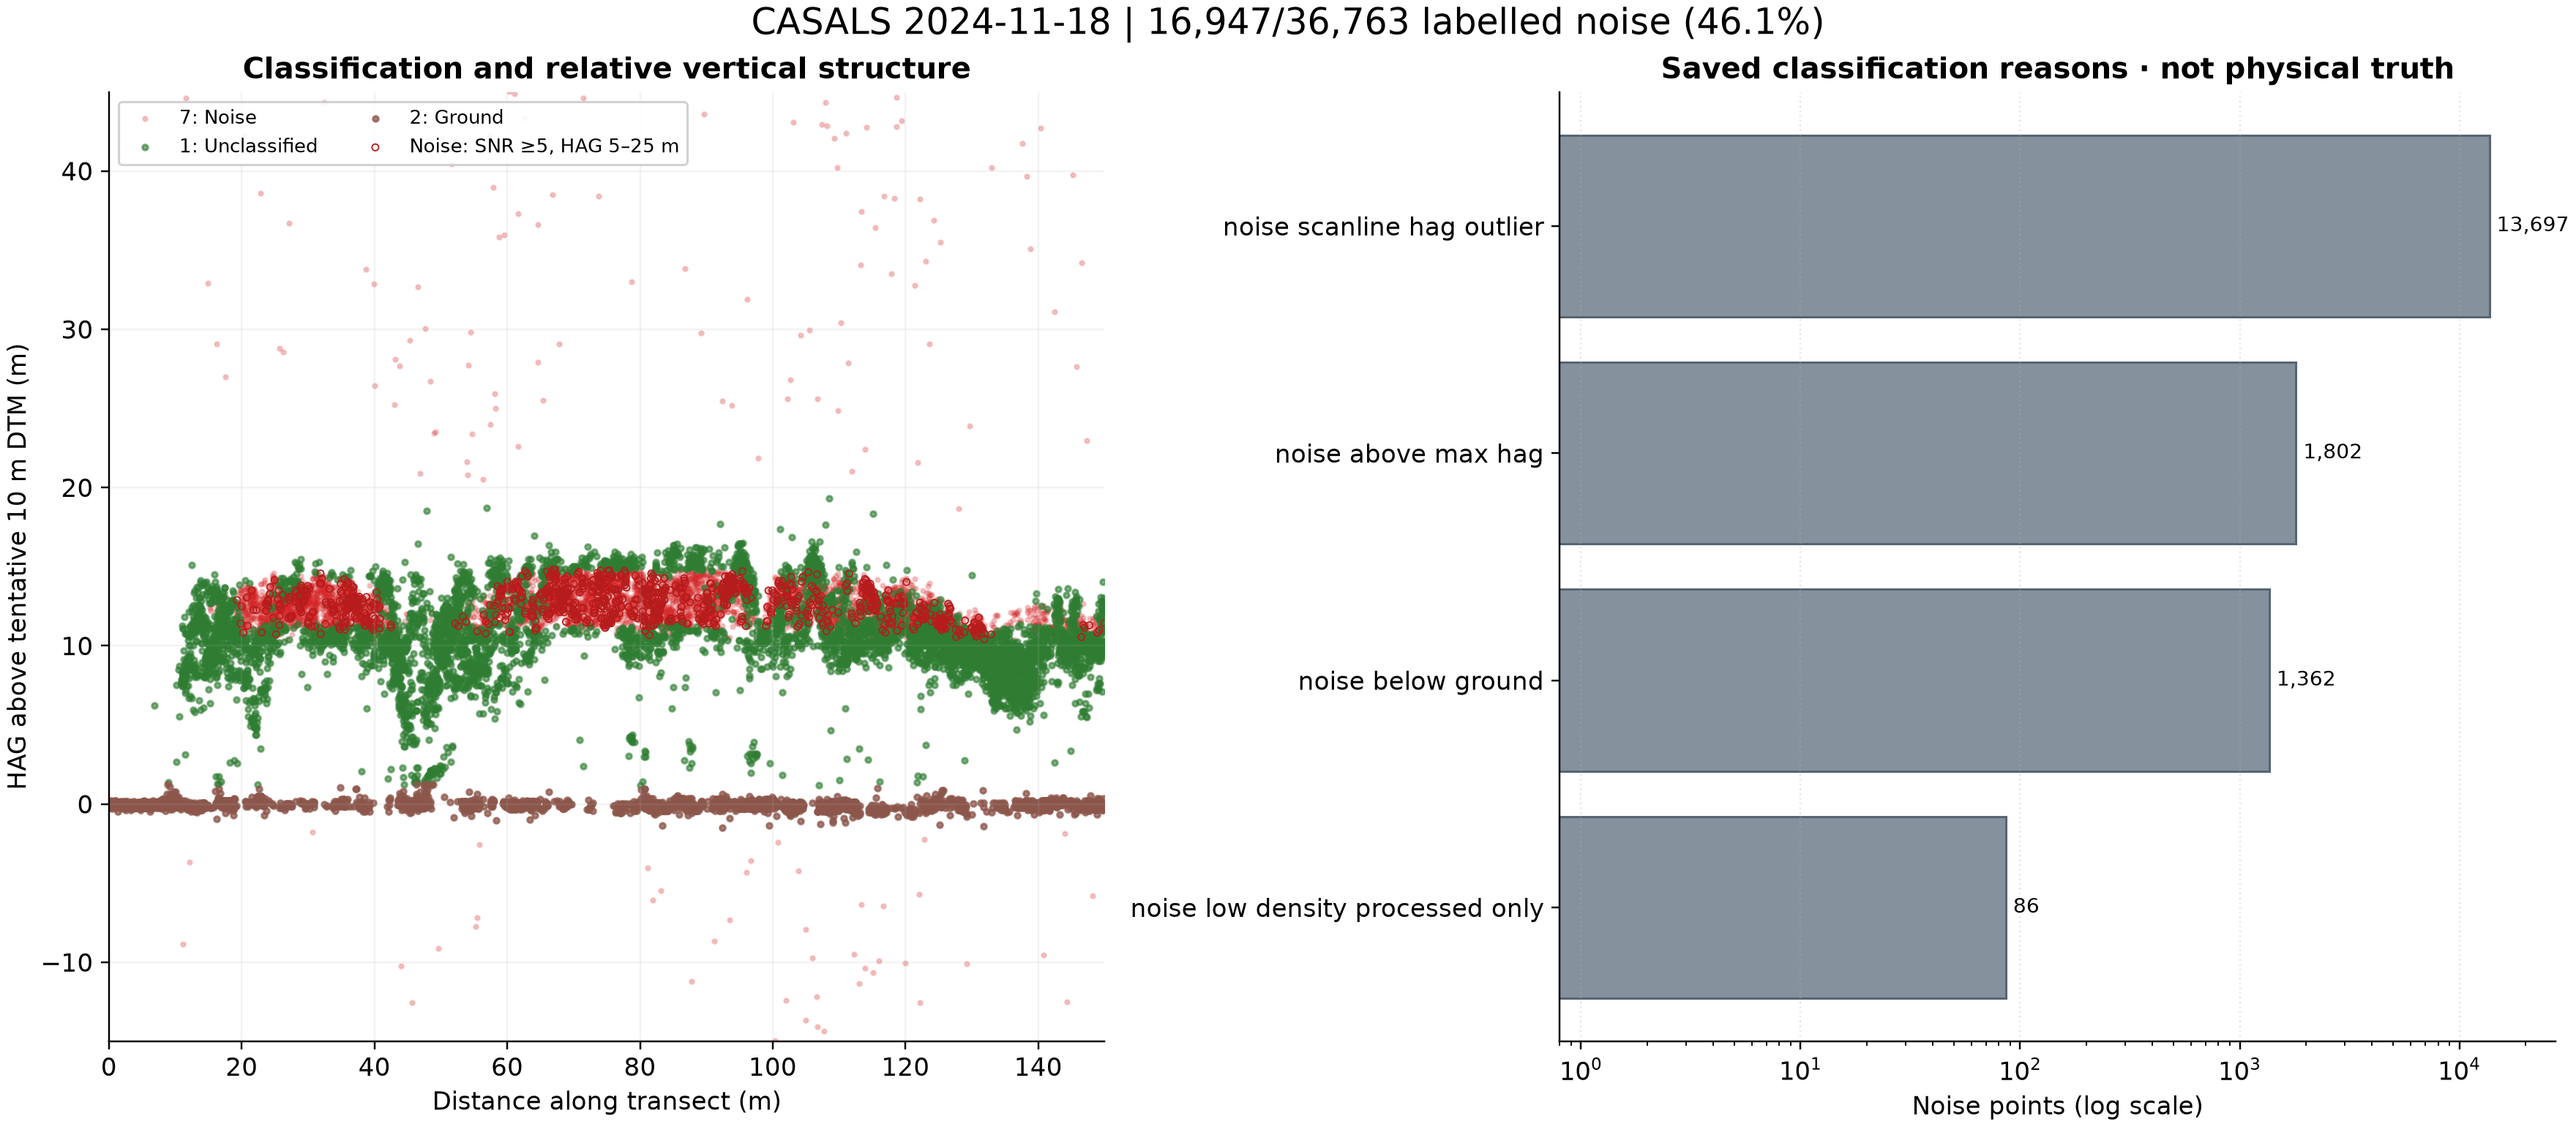

In [5]:
# Diagnose saved labels without changing classification rules.
import laspy
from casals_l1b.classification import CLASS_REASON_MAP
reason_by_pulse = np.full(len(points.pulse_index), -1, dtype=np.int16)
class_products, _ = find_products(H5_PATH, 'classified_laz', CLASSIFICATION_METADATA)
with laspy.open(class_products['classified_laz']) as src:
    if 'classification_reason' not in src.header.point_format.dimension_names:
        raise ValueError('Expected saved classification_reason is unavailable')
    for chunk in src.chunk_iterator(500_000):
        reason_by_pulse[np.asarray(chunk.point_index,int)] = np.asarray(chunk.classification_reason)
point_table['classification_reason'] = reason_by_pulse[point_table.pulse_index]
point_ground, point_support = sample_raster(dtm['dtm_tif'], point_table[['X','Y']].to_numpy(), CRS, dtm['support_mask_tif'])
point_table['tentative_HAG_m'] = point_table.refh_height_m-point_ground
with h5py.File(H5_PATH,'r') as h5:
    for field in ['track_num','sweep_num']:
        point_table[field] = np.asarray(h5[field])[point_table.pulse_index]
    geometry_finite = np.ones(len(point_table),bool)
    for field in ['instrument_longitude','instrument_latitude','instrument_altitude','rwstart_longitude','rwstart_latitude','rwstart','rwstop_longitude','rwstop_latitude','rwstop']:
        geometry_finite &= np.isfinite(np.asarray(h5[field])[point_table.pulse_index])
point_table['stored_geometry_finite'] = geometry_finite
noise = point_table[point_table['class']==7]
canopy_range_noise = noise[(noise.SNR>=5)&noise.tentative_HAG_m.between(5,25)]
reason_counts = noise.classification_reason.value_counts().sort_values(ascending=False)
track_counts = point_table.groupby('track_num')['class'].agg(total='size',noise=lambda a:int((a==7).sum()))
track_counts['noise_fraction']=track_counts.noise/track_counts.total
track_counts.to_csv(OUTPUT_DIR/'transect_track_noise.csv')
upper=[]
for lo in np.arange(0,length,10):
    g=point_table[point_table.distance_m.between(lo,lo+10,inclusive='left')]
    upper.append(dict(distance_m=lo+5,all_p95_m=g.refh_height_m.quantile(.95),nonnoise_p95_m=g.loc[g['class']!=7,'refh_height_m'].quantile(.95),
                      all_p99_m=g.refh_height_m.quantile(.99),nonnoise_p99_m=g.loc[g['class']!=7,'refh_height_m'].quantile(.99)))
high_signal_differences=[]
for lo in np.arange(0,length,10):
    g=point_table[point_table.distance_m.between(lo,lo+10,inclusive='left')&(point_table.SNR>=5)&point_table.tentative_HAG_m.between(0,25)]
    high_signal_differences.append(float(g.refh_height_m.quantile(.95)-g.loc[g['class']!=7,'refh_height_m'].quantile(.95)))
upper=pd.DataFrame(upper);upper.to_csv(OUTPUT_DIR/'transect_upper_structure.csv',index=False)
noise_diagnostic=dict(noise_count=len(noise),noise_fraction=len(noise)/len(point_table),noise_tracks=int(noise.track_num.nunique()),total_tracks=int(point_table.track_num.nunique()),high_signal_HAG0to25_max_10m_p95_difference_m=max(high_signal_differences),
    reasons={CLASS_REASON_MAP.get(int(k),str(k)):int(v) for k,v in reason_counts.items()},
    noise_elevation_quantiles_m=noise.refh_height_m.quantile([0,.1,.5,.9,1]).to_dict(),
    noise_HAG_quantiles_m=noise.tentative_HAG_m.quantile([0,.1,.5,.9,1]).to_dict(),
    noise_SNR_quantiles=noise.SNR.quantile([0,.1,.5,.9,1]).to_dict(),
    low_SNR_below5_count=int((noise.SNR<5).sum()),nonfinite_stored_geometry_count=int((~noise.stored_geometry_finite).sum()),
    high_SNR_HAG5to25_count=len(canopy_range_noise),high_SNR_HAG5to25_occupied_10m_bins=int(np.floor(canopy_range_noise.distance_m/10).nunique()),
    max_10m_p95_all_minus_nonnoise_m=float((upper.all_p95_m-upper.nonnoise_p95_m).max()),
    max_10m_p99_all_minus_nonnoise_m=float((upper.all_p99_m-upper.nonnoise_p99_m).max()),
    highest_noise_fraction_tracks=track_counts.sort_values('noise_fraction',ascending=False).head(8).reset_index().to_dict('records'),
    interpretation='Saved reasons explain rule assignment, not independently verified physical causes. High-SNR canopy-range noise remains unvalidated; no relabelling.')
fig,axes=plt.subplots(1,2,figsize=(16,7),layout='constrained')
for cls in [7,1,2]:
    g=point_table[point_table['class']==cls];g=g.iloc[::max(1,len(g)//6000)]
    alpha_val = .22 if cls==7 else (.6 if cls==1 else .75)
    size_val = 3.5 if cls==7 else 6.0
    axes[0].scatter(g.distance_m,g.tentative_HAG_m,s=size_val,c=COLORS[cls],alpha=alpha_val,label=NAMES[cls],rasterized=True)
axes[0].scatter(canopy_range_noise.distance_m,canopy_range_noise.tentative_HAG_m,s=9,facecolors='none',edgecolors='#b71c1c',lw=.6,label='Noise: SNR ≥5, HAG 5–25 m')
axes[0].set(xlabel='Distance along transect (m)',ylabel='HAG above tentative 10 m DTM (m)',ylim=(-15,45),xlim=(0,length),title='Classification and relative vertical structure')
axes[0].legend(fontsize=8.5,ncol=2,loc='upper left',framealpha=0.9);axes[0].grid(alpha=.15)
labels=[CLASS_REASON_MAP.get(int(k),str(k)).replace('_',' ') for k in reason_counts.index]
axes[1].barh(labels,reason_counts.values,color='#85929E',edgecolor='#566573');axes[1].invert_yaxis();axes[1].set_xscale('log')
for j,count in enumerate(reason_counts.values):axes[1].text(count*1.08,j,f'{count:,}',va='center',fontsize=9)
axes[1].set(xlabel='Noise points (log scale)',title='Saved classification reasons · not physical truth');axes[1].set_xlim(.8,reason_counts.max()*2)
axes[1].grid(axis='x',linestyle=':',alpha=0.3)
fig.suptitle(f'CASALS {ACQUISITION_DATE} | {len(noise):,}/{len(point_table):,} labelled noise ({len(noise)/len(point_table):.1%})',fontsize=16)
fig.savefig(OUTPUT_DIR/'transect_noise_diagnostic.png',dpi=DPI);plt.close(fig)
point_table.to_csv(OUTPUT_DIR/'transect_points.csv',index=False)
save_json(OUTPUT_DIR/'noise_diagnostic.json',noise_diagnostic)
display(noise_diagnostic)
display(Image(filename=str(OUTPUT_DIR/'transect_noise_diagnostic.png')))

## Interpretation, limits and output record
Historical NAIP (2022-06-15) shows tree crowns near the sampled elevated structures; the AOI remains probable forest canopy for CASALS 2024. The retained 150 m line has 145/151 strict DSM samples and 151/151 filled DSM and tentative DTM samples (2 m DSM / 10 m DTM). HAG is not validated tree height.

Of 16,947 noise-labelled points, 13,697 have the saved scanline-HAG-outlier reason; 1,802 are above the classifier HAG maximum, 1,362 below its ground surface and 86 low density. Noise median elevation is −20.78 m, median showcase-DTM HAG 12.62 m and median SNR 3.04; 93.8% have SNR <5. Stored geometry is finite. Noise spans 73 of 76 sampled tracks, rather than one isolated track.

There are 1,057 noise-labelled points with SNR >=5 and HAG 5–25 m across 14 ten-metre distance bins. Their structure overlaps historical tree cover and plausible elevated returns, so noise cannot uniformly be dismissed as false canopy. The high-SNR HAG 0–25 m 95th-percentile upper envelope changes by up to 3.17 m in a ten-metre bin when noise is excluded. The unconstrained envelope is dominated by extreme heights (up to +221.78 m). This is a classification limitation, not a relabelling or independent validation. Main profiles retain noise, highlight its high-SNR subset and provide the full-range inset; all 36,763 points remain in the CSV.

Source ellipsoidal conventions, realization/epoch and correction semantics remain partly unconfirmed. Tentative DTM can miss ground under dense cover. No 3DEP NAVD88 heights are overlaid.

In [6]:
selection = dict(noise_diagnostic=noise_diagnostic,h5=relative(H5_PATH),crs=f'EPSG:{CRS}',aoi=AOI,A=A,B=B,length_m=length,
    buffer_half_width_m=BUFFER_HALF_WIDTH_M,profile_step_m=PROFILE_STEP_M,
    observed_dsm_display_smoothing=dict(method='Gaussian per contiguous valid segment',sigma_m=OBSERVED_DSM_SMOOTH_SIGMA_M,source_samples='unfiltered in transect_samples.csv'),
    n_refh_points=len(point_table),class_counts=point_table['class'].value_counts().to_dict(),
    profile_valid_fractions={k:float(sample_table[k].mean()) for k in ['strict_dsm_valid','filled_dsm_valid','dtm_valid','dsm_interpolated']},
    dsm_resolution_m=DSM_RES,dtm_resolution_m=DTM_RES,dsm_crs=DSM_CRS,dtm_crs=DTM_CRS,
    product_metadata=product_metadata,classification_metadata=class_metadata,
    evidence_image=relative(ortho),evidence_provenance=relative(ortho.with_suffix('.json')),
    evidence_dates=evidence['acquisition_dates'],land_cover=LAND_COVER,confidence='probable' if REVIEWED_DEFAULT else 'unknown',
    visual_review='Tree crowns/shadows in all five November 18 candidates; candidate 1 field edge and small clearing provide lower-surface contrast. Historical image inspected; 2024 footprint truth unconfirmed.',
    transect_reason='Retained fixed actual sampled strip through lower Refh edge zones and historical tree cover; high DTM support; no fitted image shift.',
    main_profile_ylim_m=main_limits,points_outside_main_ylim=int(((point_table.refh_height_m<main_limits[0])|(point_table.refh_height_m>main_limits[1])).sum()),
    limitations=['Tentative DTM and HAG are not validated ground/tree height','NAIP predates CASALS by about 2.4 years','No independent footprint registration or vertical validation'],
    outputs=[relative(OUTPUT_DIR/name) for name in ['candidate_evidence_board.png','candidate_profile_metadata.csv','candidate_profile_samples.csv','aoi_overview.png','transect_profile.png','transect_profile_ground_vs_nonground.png','transect_comparison_board.png','transect_points.csv','transect_samples.csv','transect_noise_diagnostic.png']])
save_json(OUTPUT_DIR/'selection_metadata.json',selection)
display(pd.DataFrame({'file':sorted(p.name for p in OUTPUT_DIR.iterdir() if p.is_file())}))


,file
0,aoi_candidates.csv
1,aoi_naip.json
2,aoi_naip.tif
3,aoi_overview.png
4,candidate_1_naip.json
5,candidate_1_naip.tif
6,candidate_2_naip.json
7,candidate_2_naip.tif
8,candidate_3_naip.json
9,candidate_3_naip.tif
